In [1]:
using Plots;pythonplot()
using Statistics
using DataFrames, CSV
using ProgressMeter

## Telomeric repeats

In [25]:
dir_source="/workdir/tx84/Research/2024_LepChromosomes/00.assembly/Papilio_bianor/02.hifiasm.no_mito.D10.k63.w51.max-kocc.1000.hg-size.520m.v0_20_0.s.0_5/scaffold.p_ctg.no_circ/05.yahs/out_JBAT.review_02.FINAL.motifs"

cd(dir_source)

In [26]:
df_plus=DataFrame(CSV.File("coverage.motif_CCTAA_2copies.merged.strand_plus.w100s100.bed",header=false))
df_minus=DataFrame(CSV.File("coverage.motif_CCTAA_2copies.merged.strand_minus.w100s100.bed",header=false));

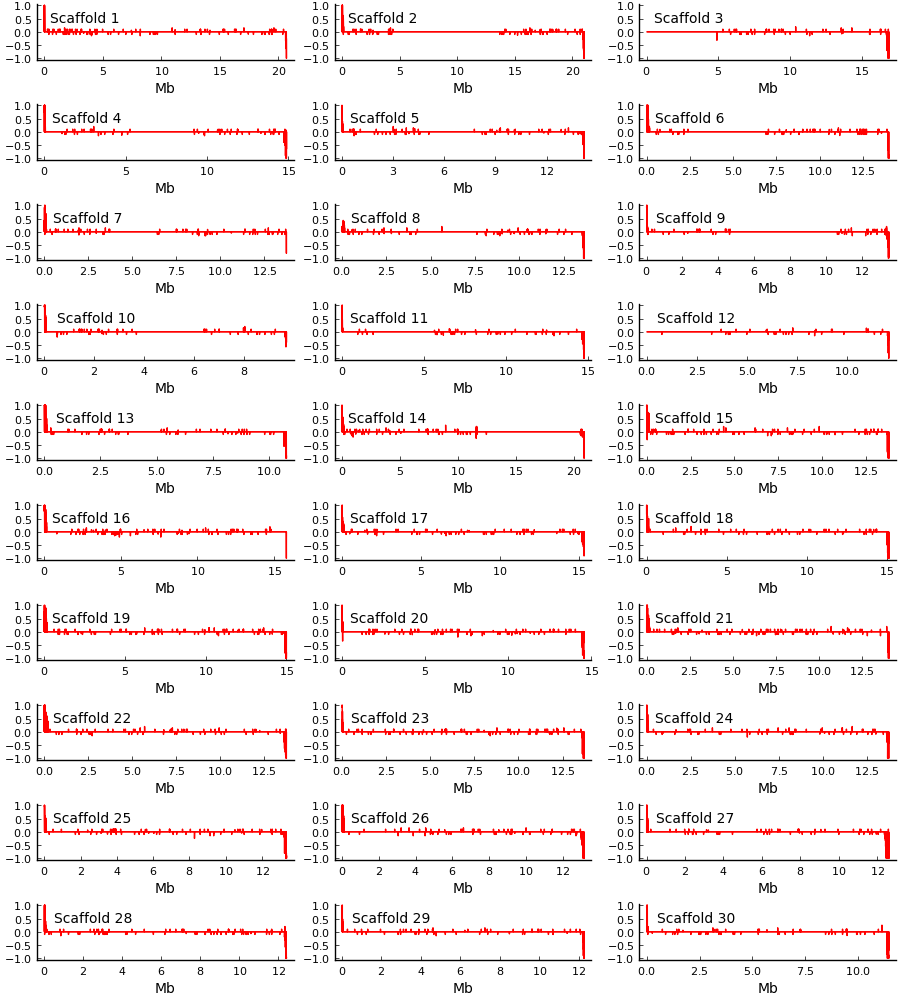

In [30]:
fig = plot(size=(900,1000),layout=(10,3))

for i in 1:30

    chr=i

    df_chr_plus = df_plus[df_plus[:,1] .== "scaffold_$(chr)",:]
    df_chr_minus = df_minus[df_minus[:,1] .== "scaffold_$(chr)",:]
    x_plus = (df_chr_plus[:,2] .+ df_chr_plus[:,3])./2
    y_plus = df_chr_plus[:,7]
    x_minus = (df_chr_minus[:,2] .+ df_chr_minus[:,3])./2
    y_minus = df_chr_minus[:,7]
    
    plot!(fig,x_plus./1e6,y_plus,
        label="",
        ylims=(-1.05,1.05),
        xlabel="Mb",
        xguidefontsize=10,
        linecolor=:red,
        grid=:off,
        subplot=i
    )
    plot!(fig,x_minus./1e6,-y_minus,
        label="",
        linecolor=:red,
        subplot=i
    )
    annotate!(fig,[(0.5,0.5,Plots.text("Scaffold $(chr)",10,:left))],subplot=i)

end

fig

In [31]:
dir_out="~/Research/2024_LepChromosomes/Papilio_bianor_assembly/hifiasm.no_mito.D10.k63.w51.max-kocc.1000.hg-size.520m.v0_20_0.s.0_5/out_JBAT.review_02.FINAL/Telomeres"
prefix = "coverage.motif_CCTAA_2copies.merged.w100s100.scaffolds_1_to_30"

savefig(fig,"$(dir_out)/$(prefix).png")
savefig(fig,"$(dir_out)/$(prefix).pdf")

"/home/tx84/Research/2024_LepChromosomes/Papilio_bianor_assembly/hifiasm.no_mito.D10.k63.w51.max-kocc.1000.hg-size.520m.v0_20_0.s.0_5/out_JBAT.review_02.FINAL/Telomeres/coverage.motif_CCTAA_2copies.merged.w100s100.scaffolds_1_to_30.pdf"

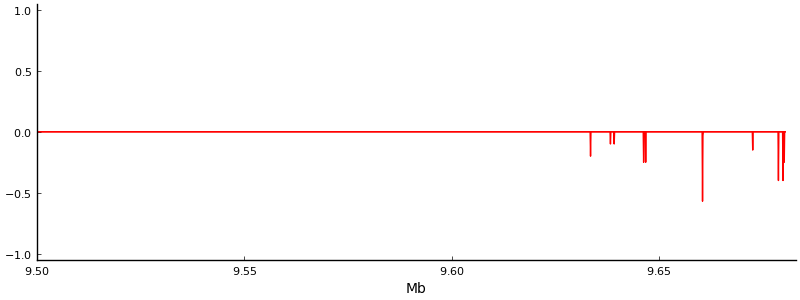

In [29]:
# Blow up the plot

fig = plot(size=(800,300))

chr=10

df_chr_plus = df_plus[df_plus[:,1] .== "scaffold_$(chr)",:]
df_chr_minus = df_minus[df_minus[:,1] .== "scaffold_$(chr)",:]
x_plus = (df_chr_plus[:,2] .+ df_chr_plus[:,3])./2
y_plus = df_chr_plus[:,7]
x_minus = (df_chr_minus[:,2] .+ df_chr_minus[:,3])./2
y_minus = df_chr_minus[:,7]

plot!(fig,x_plus./1e6,y_plus,
    label="",
    ylims=(-1.05,1.05),
xlims=(9.5,9.683),
    xlabel="Mb",
    xguidefontsize=10,
    linecolor=:red,
    grid=:off,
)
plot!(fig,x_minus./1e6,-y_minus,
    label="",
    linecolor=:red,
)
annotate!(fig,[(0,0.5,Plots.text("Scaffold $(chr)",10,:left))])
